# testing HBV from .py 

In [1]:
# setup imports
import sys
from pathlib import Path

import numpy as np
import xarray as xr

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

from src.forcing import (
    load_lumped_forcing,
    plot_ERA5_forcing,
)
from src.models import generate_HBV_parameters, plot_HBV_output, run_HBV_model, save_HBV_results
from src.paths import *
from src.plotting import plot_precipitation_map, plot_shapefile_overview
from src.utils import get_integer_multiple_bounds

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [ ]:
# The time-window of the experiment
experiment_start_date = "1940-01-01T00:00:00Z"
experiment_end_date = "1990-12-31T00:00:00Z"

shapefile_name = "Tyumen_Aryk_GRDC"

# ERA5_forcing = setup_ERA5_forcing(shapefile_name, experiment_start_date, experiment_end_date)
# ERA5_forcing = load_lumped_forcing(shapefile_name, , )

In [ ]:
ERA5_forcing_loaded = load_lumped_forcing("Tyumen_Aryk_GRDC", "ERA5", "1940-1990")

In [ ]:
plot_ERA5_forcing(ERA5_forcing_loaded)

# HBV model run

In [ ]:
parameter_set = [
    7.085,  # Imax
    0.837,  # Ce
    76.373,  # Sumax
    1.112,  # Beta
    0.245,  # Pmax
    7.801,  # Tlag
    0.096,  # Kf
    0.003,  # Ks
    0.226,  # FM
]

initial_conditions = np.array(
    [
        0,  # Si
        100,  # Su
        0,  # Sf
        5,  # Ss
        0,  # Sp
    ]
)

In [ ]:
Q_modelled = run_HBV_model(
    forcing=ERA5_forcing_loaded,
    parameter_set=parameter_set,
    initial_conditions=initial_conditions,
    show_progress=True,  # shows tqdm progress bar
)


print(Q_modelled.head())

In [ ]:
plot_HBV_output(Q_modelled)

In [ ]:
files = save_HBV_results(Q_modelled, shape_name=shapefile_name, forcing_type="ERA5")

In [3]:
# Determine bounding box
shape_name = "AralSea_basin"
shapefile = SHAPEFILES / shape_name / f"{shape_name}.shp"

lon_min_f, lat_min_f, lon_max_f, lat_max_f = get_integer_multiple_bounds(
    shapefile,  #   <----- add shapefiles here
    multiple=3,  # makes sure resolution is always correct
)
print(lon_min_f, lat_min_f, lon_max_f, lat_max_f)

57 34 81 52


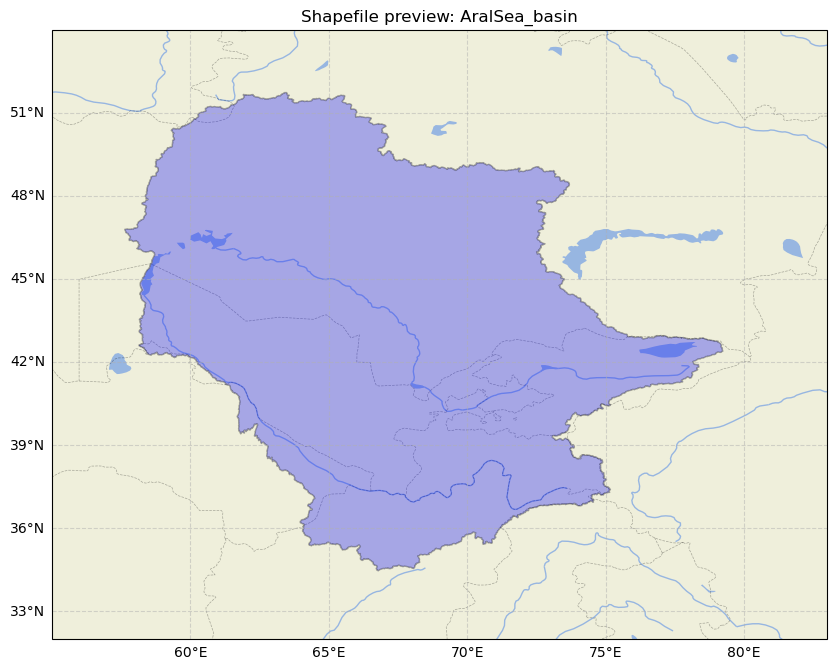

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import fiona
import matplotlib.pyplot as plt
from shapely.geometry import shape

shp = SHAPEFILES / shape_name / f"{shape_name}.shp"

# Create figure and Cartopy axes
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add background features

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.RIVERS, linewidth=1)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.OCEAN, facecolor="#a2daff", edgecolor="none")
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle="--", alpha=0.3)

# Plot shapefile geometries
with fiona.open(shp) as src:
    for feat in src:
        geom = shape(feat["geometry"])
        ax.add_geometries(
            [geom], crs=ccrs.PlateCarree(), facecolor="blue", edgecolor="black", alpha=0.3
        )

# Set extent to shapefile bounds (with small padding)
with fiona.open(shp) as src:
    minx, miny, maxx, maxy = src.bounds
ax.set_extent([lon_min_f - 2, lon_max_f + 2, lat_min_f - 2, lat_max_f + 2], crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Add title
ax.set_title(f"Shapefile preview: {shape_name}")

plt.show()

In [ ]:
# experiment_start_date = "1940-01-01T00:00:00Z"
# experiment_end_date = "1940-05-31T00:00:00Z"
# PCR_Forcing = setup_ERA5_PCR_forcing("AralSea_basin",experiment_start_date,experiment_end_date)

In [ ]:
print(PCR_Forcing)

In [ ]:
for file_name in [PCR_Forcing.temperatureNC, PCR_Forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{PCR_Forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-1).plot(cmap="coolwarm", robust=True, size=5)

(<Figure size 1000x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Shapefile overview: Kazalinsk_GRDC.shp'}>)

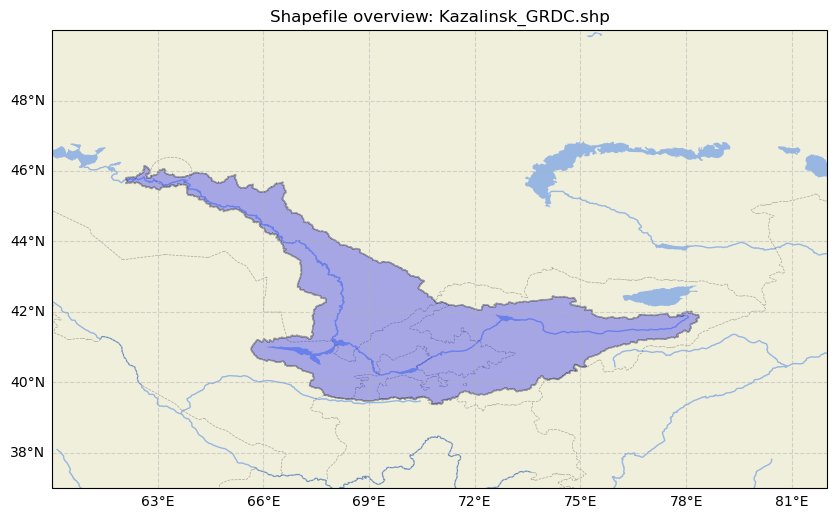

In [2]:
# Determine bounding box
shape_name = "Kazalinsk_GRDC"
shapefile = SHAPEFILES / shape_name / f"{shape_name}.shp"
plot_shapefile_overview(shapefile)

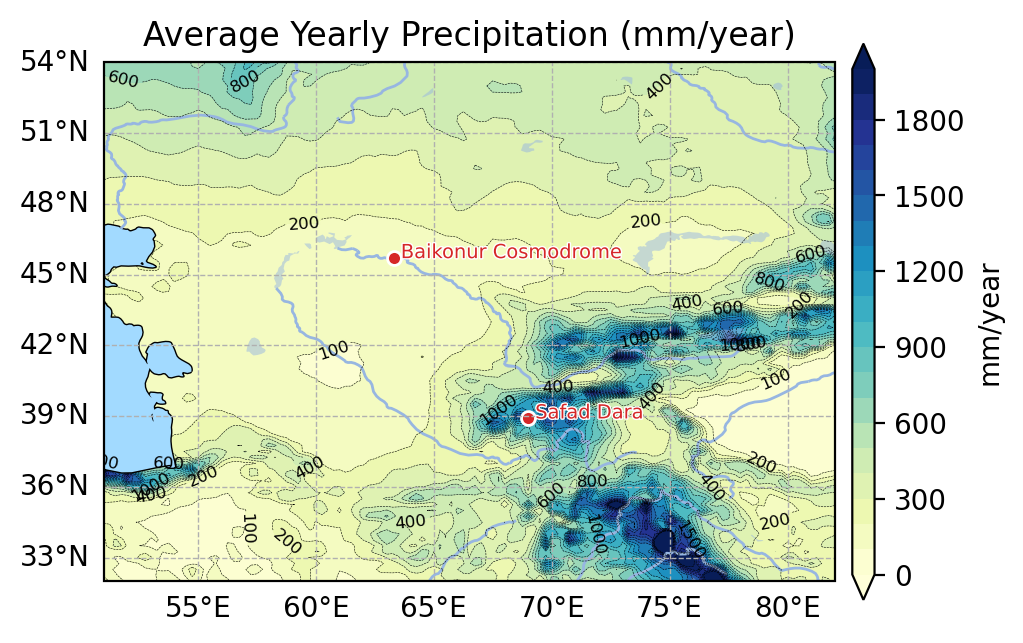

(<Figure size 1000x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Average Yearly Precipitation (mm/year)'}>)

In [2]:
file_name_pr = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/forcing_5570/AralSeaBasin/pcrglobwb/work/diagnostic/script/pcrglobwb_OBS6_ERA5_reanaly_1_day_pr_1955-1970_AralSeaBasin.nc"
# open the file
ds = xr.open_dataset(file_name_pr)
# convert to dataArray
da = ds["pr"]

# convert to mm/year and take average
da_yearly = da.resample(time="1YE").sum(dim="time") * 1000
da_avg_year = da_yearly.mean(dim="time")  # average yearly precipitation

stations = [
    {"lat": 38.9, "lon": 69, "name": "Safad Dara"},
    {"lat": 45.7, "lon": 63.3, "name": "Baikonur Cosmodrome"},
]

plot_precipitation_map(
    da_avg_year, contour_lines=[100, 200, 400, 600, 800, 1000, 1500], stations=stations
)

In [2]:
x0 = np.mean(generate_HBV_parameters(100), axis=0)

In [3]:
x0

array([1.26384855e+01, 6.16247306e-01, 4.42575065e+02, 2.22247148e+00,
       1.55793686e-01, 7.19744186e+00, 1.47799458e-02, 5.06830777e-03,
       4.00857925e-01])